## import the library

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge , ElasticNet
from sklearn.metrics import mean_squared_error
import pandas as pd
import seaborn as sns

# load the dataset

In [2]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='House Price')

In [3]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: House Price, dtype: float64

## correlation

<Axes: >

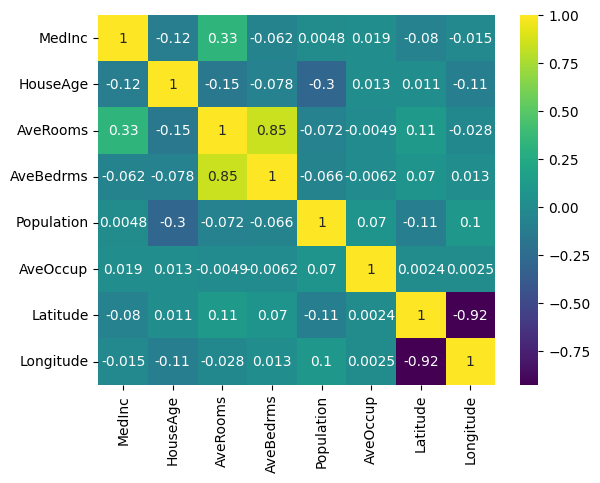

In [6]:
sns.heatmap(X.corr(),annot=True,cmap='viridis')

In [7]:
X = X.drop(columns=['Latitude','Longitude','AveRooms'])

<Axes: >

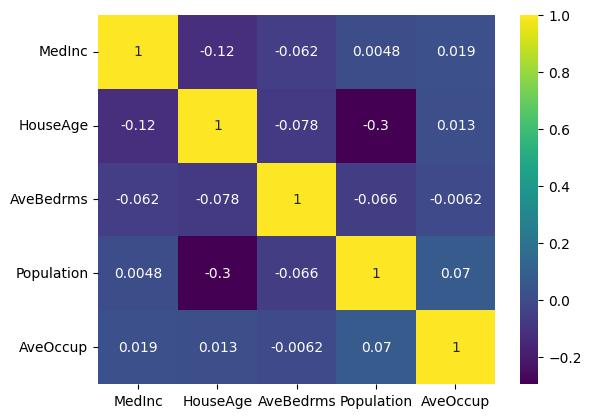

In [8]:
sns.heatmap(X.corr(),annot=True,cmap='viridis')

#### Scaling

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [10]:
X = scaler.fit_transform(X)

In [11]:
y = y.values.reshape(-1, 1)

In [12]:
y = scaler.fit_transform(y)

In [13]:
y = pd.Series(y.flatten(), name='Scaled House Price')

In [14]:
y

0        2.129631
1        1.314156
2        1.258693
3        1.165100
4        1.172900
           ...   
20635   -1.115804
20636   -1.124470
20637   -0.992746
20638   -1.058608
20639   -1.017878
Name: Scaled House Price, Length: 20640, dtype: float64

## Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
linear_model = LinearRegression()
lasso_model = Lasso(alpha=0.1)
ridge_model = Ridge(alpha=0.1)
elasticnet_model = ElasticNet(alpha=0.1, l1_ratio=0.5)

In [17]:
X.shape

(20640, 5)

In [18]:
y.shape

(20640,)

### Linear Regression 
LossOLS = [(yᵢ - f(xᵢ))²] / (2 * m)

In [19]:
linear_model.fit(X_train, y_train)

LinearRegression()

### Lasso Regression
Losslasso = LossOLS + λ∑pj=1 ∣βj∣

In [20]:
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.1)

### Ridge Regression
Lossridge = LossOLS + λ∑pj=1 βj2

In [21]:
ridge_model.fit(X_train, y_train)

Ridge(alpha=0.1)

### Elastic Net Regression
Losselastic net = LossOLS + λ1 ∑pj=1 ∣βj∣+ λ2 ∑pj=1 βj2

In [22]:
elasticnet_model.fit(X_train, y_train)

ElasticNet(alpha=0.1)

In [23]:
linear_train_mse = mean_squared_error(y_train, linear_model.predict(X_train))
linear_test_mse = mean_squared_error(y_test, linear_model.predict(X_test))

lasso_train_mse = mean_squared_error(y_train, lasso_model.predict(X_train))
lasso_test_mse = mean_squared_error(y_test, lasso_model.predict(X_test))

ridge_train_mse = mean_squared_error(y_train, ridge_model.predict(X_train))
ridge_test_mse = mean_squared_error(y_test, ridge_model.predict(X_test))

elasticnet_train_mse = mean_squared_error(y_train, elasticnet_model.predict(X_train))
elasticnet_test_mse = mean_squared_error(y_test, elasticnet_model.predict(X_test))

print("Linear Regression Model - Train MSE ", linear_train_mse)
print("Linear Regression Model - Test MSE: ", linear_test_mse)

print("Lasso Regression Model - Train MSE ", lasso_train_mse)
print("Lasso Regression Model - Test MSE: ", lasso_test_mse)

print("Ridge Regression Model - Train MSE: ", ridge_train_mse)
print("Ridge Regression Model - Test MSE: ", ridge_test_mse)

print("ElasticNet Regression Model - Train MSE: ", elasticnet_train_mse)
print("ElasticNet Regression Model - Test MSE: ", elasticnet_test_mse)

Linear Regression Model - Train MSE  0.48603747419853516
Linear Regression Model - Test MSE:  0.4962375824858572
Lasso Regression Model - Train MSE  0.511821944980741
Lasso Regression Model - Test MSE:  0.5171919690648117
Ridge Regression Model - Train MSE:  0.48603747422173754
Ridge Regression Model - Test MSE:  0.49623739470805717
ElasticNet Regression Model - Train MSE:  0.5001201979747614
ElasticNet Regression Model - Test MSE:  0.5062503665354645
